The Advanced Computing Center for Research and Education
Project Overview The Advanced Computing Center for Research and Education (ACCRE) operates Vanderbilt University's high-performance computing cluster. Jobs submitted to ACCRE are managed by the slurm scheduler, which tracks compute and memory resources.

ACCRE staff have hypothesized that the scheduler sometimes becomes unresponsive because it is processing large bursts of job completions. This especially affects automated job submitters, such as members of the Open Science Grid.

Your goal is to evaluate whether the data supports the hypothesis of bursts of job completions contributing to scheduler unresponsiveness.

You are provided three datasets:

fullsample.csv: Contains slurm job records. Job completions correspond to jobs in the "COMPLETED" state with exit code "0:0".
slurm_wrapper_ce5.log, slurm_wrapper_ce6.log: These log files contain every slurm command executed by the CE5 and CE6 servers (gateways to the Open Science Grid).
Unresponsive periods are indicated by "sbatch" commands from user 9204 that have:
return code = 1
execution time > 15 seconds

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


**Phase 1: Explore the Data**

Objectives:

Understand the purpose of each dataset.
Inspect column types, sizes, and example rows.

In [2]:
jobs = pd.read_csv("data/fullsample.csv")
jobs.head(5)

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,PARTITION,EXITCODE
0,30616928,RUNNING,2021-07-31T22:15:00,Unknown,2048Mn,0,10:04:00,67-22:14:22,1,1,production,0:0
1,30853133,COMPLETED,2021-08-06T11:36:09,2021-09-05T11:36:32,262144Mn,20604.62M,30-00:00:00,30-00:00:23,1,1,cgw-platypus,0:0
2,30858137,COMPLETED,2021-08-06T19:04:39,2021-09-05T19:04:53,204800Mn,57553.77M,30-00:00:00,30-00:00:14,1,32,cgw-tbi01,0:0
3,30935078,COMPLETED,2021-08-09T16:52:51,2021-09-07T20:52:55,65536Mn,20577.96M,29-04:00:00,29-04:00:04,1,8,cgw-platypus,0:0
4,31364111_2,COMPLETED,2021-08-17T07:45:07,2021-09-10T16:45:24,16384Mn,9733.43M,24-09:00:00,24-09:00:17,1,1,production,0:0


In [3]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7395885 entries, 0 to 7395884
Data columns (total 12 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   JOBID      object
 1   STATE      object
 2   BEGIN      object
 3   END        object
 4   REQMEM     object
 5   USEDMEM    object
 6   REQTIME    object
 7   USEDTIME   object
 8   NODES      int64 
 9   CPUS       int64 
 10  PARTITION  object
 11  EXITCODE   object
dtypes: int64(2), object(10)
memory usage: 677.1+ MB


In [4]:
print(jobs.columns)

Index(['JOBID', 'STATE', 'BEGIN', 'END', 'REQMEM', 'USEDMEM', 'REQTIME',
       'USEDTIME', 'NODES', 'CPUS', 'PARTITION', 'EXITCODE'],
      dtype='object')


In [5]:
total_nan = jobs.isna().sum()
print(total_nan)

JOBID        0
STATE        0
BEGIN        0
END          0
REQMEM       0
USEDMEM      0
REQTIME      0
USEDTIME     0
NODES        0
CPUS         0
PARTITION    0
EXITCODE     0
dtype: int64


In [6]:
ce5 = pd.read_csv("data/slurm_wrapper_ce5.log",
                  header=None,
                  delimiter=' - ',
                  engine='python')

ce5.rename(columns={
    0: "Date",
    1: "User",
    2: "Retry",
    3: "Time",
    4: "Returncode",
    5: "Command"
}, inplace=True)


In [7]:
ce5.shape

(4770893, 6)

In [8]:
ce5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4770893 entries, 0 to 4770892
Data columns (total 6 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Date        object
 1   User        object
 2   Retry       object
 3   Time        object
 4   Returncode  object
 5   Command     object
dtypes: object(6)
memory usage: 218.4+ MB


* The ce5 data contains about 4.77M rows and 6 columns

In [9]:
ce5.head()

,Date,User,Retry,Time,Returncode,Command
0,2020-10-16 08:15:39.278699,user 0,retry 0,time 0.07347559928894043,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
1,2020-10-16 08:18:08.313309,user 0,retry 0,time 0.18363237380981445,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
2,2020-10-16 08:22:48.128689,user 0,retry 0,time 0.07547116279602051,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
3,2020-10-16 08:25:13.257408,user 0,retry 0,time 0.09484362602233887,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
4,2020-10-16 08:31:01.460723,user 0,retry 0,time 0.07498788833618164,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."


In [10]:
ce6 = pd.read_csv("data/slurm_wrapper_ce6.log",
                  header=None,
                  delimiter=' - ',
                  engine='python')

ce6.rename(columns={
    0: "Date",
    1: "User",
    2: "Retry",
    3: "Time",
    4: "Returncode",
    5: "Command"
}, inplace=True)


In [11]:
ce6.head(5)

,Date,User,Retry,Time,Returncode,Command
0,2020-10-16 10:37:44.163454,user 9202,retry 0,time 0.08495402336120605,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."
1,2020-10-16 10:37:44.206654,user 9202,retry 0,time 0.08943057060241699,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."
2,2020-10-16 10:37:44.218760,user 9202,retry 0,time 0.05928945541381836,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."
3,2020-10-16 10:37:44.256403,user 9202,retry 0,time 0.038695573806762695,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."
4,2020-10-16 10:37:44.611603,user 9202,retry 0,time 0.03343677520751953,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."


* The column names were changed from numerical to text format.
* Both the ce5 and ce6 data type contained mixed data types, such as numbers and text.

In [12]:
combined_ce5_ce6 = pd.concat([ce5, ce6], ignore_index=True)


* Combined both cs5 and ce6 DataFrames.

In [13]:
combined_ce5_ce6['User'] = (
    combined_ce5_ce6['User']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype("Int64")
)

combined_ce5_ce6['Retry'] = (
    combined_ce5_ce6['Retry']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype("Int64")
)

combined_ce5_ce6['Returncode'] = (
    combined_ce5_ce6['Returncode']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype("Int64")
)

combined_ce5_ce6['Time'] = (
    combined_ce5_ce6['Time']
    .astype(str)
    .str.extract(r'(\d+\.\d+)')
    .astype(float)
)

In [14]:
combined_ce5_ce6.head(5)

,Date,User,Retry,Time,Returncode,Command
0,2020-10-16 08:15:39.278699,0,0,0.073476,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
1,2020-10-16 08:18:08.313309,0,0,0.183632,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
2,2020-10-16 08:22:48.128689,0,0,0.075471,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
3,2020-10-16 08:25:13.257408,0,0,0.094844,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
4,2020-10-16 08:31:01.460723,0,0,0.074988,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."


* The ce5 and ce6 DataFrames originally contained mixed data types, including numbers and text. These DataFrames were then combined and transformed into clean DataFrames.

**Phase 2: Clean and Transform the Data**

Objectives:

* Extract job completions from fullsample.csv.

* Parse CE5 and CE6 logs to identify unresponsive events.

Rule:
Unresponsive periods are indicated by "sbatch" commands from user 9204 that have:
return code = 1
execution time > 15 seconds

* Parse and clean the columns in the ce5 and ce6 DataFrames.
* Identify unresponsive events in both DataFrames.

In [15]:
res_unres = combined_ce5_ce6[
    (combined_ce5_ce6['User'] == 9204) &
    (combined_ce5_ce6['Returncode'] == 1) &
    (combined_ce5_ce6['Time'] > 15) &
    (combined_ce5_ce6['Command'].str.contains("sbatch", case=False, na=False))
].copy()

print("Total unresponsive events:", len(res_unres))
print(res_unres.head())

Total unresponsive events: 3296
                             Date  User  Retry       Time  Returncode  \
49958  2020-10-18 06:53:44.272915  9204      0  20.038464           1   
49972  2020-10-18 06:54:04.322412  9204      1  20.048906           1   
50467  2020-10-18 07:47:25.825172  9204      0  20.082628           1   
50473  2020-10-18 07:47:45.871008  9204      1  20.045221           1   
50582  2020-10-18 07:53:33.972840  9204      0  20.041486           1   

                                                 Command  
49958  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  
49972  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  
50467  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  
50473  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  
50582  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  


In [16]:
res_unres = combined_ce5_ce6[
    (combined_ce5_ce6['User'] == 9204) &
    (combined_ce5_ce6['Command'].str.contains("sbatch", case=False, na=False))
].copy()

unresponsive = (res_unres['Returncode'] == 1) & (res_unres['Time'] > 15)

res_unres['Status'] = 'Responsive'
res_unres.loc[unresponsive, 'Status'] = 'Unresponsive'

print(res_unres['Status'].value_counts())

Status
Responsive      57951
Unresponsive     3296
Name: count, dtype: int64


* The number of unresponsive events was identified in the both ce5 and ce6 datasets.

* Extract job completions from fullsample.csv.

In [17]:
jobs_completed = jobs[jobs['STATE'].str.contains('COMPLETED', na=False)].copy()
jobs_completed

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,PARTITION,EXITCODE
1,30853133,COMPLETED,2021-08-06T11:36:09,2021-09-05T11:36:32,262144Mn,20604.62M,30-00:00:00,30-00:00:23,1,1,cgw-platypus,0:0
2,30858137,COMPLETED,2021-08-06T19:04:39,2021-09-05T19:04:53,204800Mn,57553.77M,30-00:00:00,30-00:00:14,1,32,cgw-tbi01,0:0
3,30935078,COMPLETED,2021-08-09T16:52:51,2021-09-07T20:52:55,65536Mn,20577.96M,29-04:00:00,29-04:00:04,1,8,cgw-platypus,0:0
4,31364111_2,COMPLETED,2021-08-17T07:45:07,2021-09-10T16:45:24,16384Mn,9733.43M,24-09:00:00,24-09:00:17,1,1,production,0:0
5,31364111_3,COMPLETED,2021-08-17T07:45:07,2021-09-06T16:17:34,16384Mn,9708.04M,24-09:00:00,20-08:32:27,1,1,production,0:0
...,...,...,...,...,...,...,...,...,...,...,...,...
7395880,25493434,COMPLETED,2020-10-31T23:39:00,2020-10-31T23:40:46,2000Mn,0.09M,2-00:00:00,00:01:46,1,1,sam,0:0
7395881,25493435,COMPLETED,2020-10-31T23:39:13,2020-10-31T23:40:38,2000Mn,187.92M,2-00:00:00,00:01:25,1,1,sam,0:0
7395882,25493476,COMPLETED,2020-10-31T23:46:29,2020-10-31T23:49:43,4096Mc,803.97M,12:00:00,00:03:14,1,1,production,0:0
7395883,25493515,COMPLETED,2020-10-31T23:49:44,2020-10-31T23:51:40,2000Mn,0.09M,2-00:00:00,00:01:56,1,1,sam,0:0


**Create analysis-ready features (time windows, completion counts, unresponsiveness indicators).**

* Combined three datasets into a single DataFrame suitable for analysis.

In [18]:
combined_data = pd.concat([jobs, res_unres], ignore_index=True)


In [19]:
combined_data.head(2)

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,PARTITION,EXITCODE,Date,User,Retry,Time,Returncode,Command,Status
0,30616928,RUNNING,2021-07-31T22:15:00,Unknown,2048Mn,0,10:04:00,67-22:14:22,1.0,1.0,production,0:0,NaN,<NA>,<NA>,NaN,<NA>,NaN,NaN
1,30853133,COMPLETED,2021-08-06T11:36:09,2021-09-05T11:36:32,262144Mn,20604.62M,30-00:00:00,30-00:00:23,1.0,1.0,cgw-platypus,0:0,NaN,<NA>,<NA>,NaN,<NA>,NaN,NaN


In [20]:
combined_data["Date"] = pd.to_datetime(combined_data["Date"], errors="coerce")

In [21]:
combined_data['Timestamp'] = (
    combined_data['Date'].fillna(combined_data['END'])
)

combined_data['Timestamp'] = pd.to_datetime(combined_data['Timestamp'], format='mixed', errors='coerce')

combined_data = combined_data.dropna(subset=['Timestamp'])

combined_data = combined_data.set_index('Timestamp').sort_index()

for window in ['1min', '5min', '15min']:
    combined_data[f'Events_{window}'] = (
        combined_data['User']
        .rolling(window=window)
        .count()
    )

* Converted the 'Date' column to datetime objects.

In [22]:
combined_data.tail(5)

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,...,Date,User,Retry,Time,Returncode,Command,Status,Events_1min,Events_5min,Events_15min
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-10-07 21:30:31.591816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-10-07 21:30:31.591816,9204,0,0.030386,0,"command ['/usr/bin/sbatch', '/tmp/condor_g_scr...",Responsive,1.0,1.0,2.0
2021-10-07 21:39:15.524139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-10-07 21:39:15.524139,9204,0,0.033684,0,"command ['/usr/bin/sbatch', '/tmp/condor_g_scr...",Responsive,1.0,1.0,2.0
2021-10-07 21:44:59.008524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-10-07 21:44:59.008524,9204,0,0.029954,0,"command ['/usr/bin/sbatch', '/tmp/condor_g_scr...",Responsive,1.0,1.0,3.0
2021-10-07 21:53:47.800229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-10-07 21:53:47.800229,9204,0,0.030737,0,"command ['/usr/bin/sbatch', '/tmp/condor_g_scr...",Responsive,1.0,1.0,3.0
2021-10-07 22:00:20.919558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-10-07 22:00:20.919558,9204,0,0.028496,0,"command ['/usr/bin/sbatch', '/tmp/condor_g_scr...",Responsive,1.0,1.0,2.0


* Completion counts.

In [23]:
completion_counts = combined_data['STATE'] == 'COMPLETED'
running_counts = combined_data['STATE'] == 'RUNNING'

for window in ['1min', '5min', '15min']:
    
    combined_data[f'Completed_{window}'] = completion_counts.rolling(window=window).sum()
    combined_data[f'Running_{window}'] = running_counts.rolling(window=window).sum()
    
print(f"Total completed jobs: {completion_counts.sum()}")
print(f"Total running jobs: {running_counts.sum()}")

Total completed jobs: 7375084
Total running jobs: 0


* Unresponsive events.

In [24]:
combined_data.columns


Index(['JOBID', 'STATE', 'BEGIN', 'END', 'REQMEM', 'USEDMEM', 'REQTIME',
       'USEDTIME', 'NODES', 'CPUS', 'PARTITION', 'EXITCODE', 'Date', 'User',
       'Retry', 'Time', 'Returncode', 'Command', 'Status', 'Events_1min',
       'Events_5min', 'Events_15min', 'Completed_1min', 'Running_1min',
       'Completed_5min', 'Running_5min', 'Completed_15min', 'Running_15min'],
      dtype='object')

In [25]:
combined_data.head(2)

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,...,Status,Events_1min,Events_5min,Events_15min,Completed_1min,Running_1min,Completed_5min,Running_5min,Completed_15min,Running_15min
Timestamp,,,,,,,,,,,,,,,,,,,,,
2020-10-01 00:10:15,24460577,COMPLETED,2020-10-01T00:05:55,2020-10-01T00:10:15,4096Mc,868.77M,12:00:00,00:04:20,1.0,1.0,...,NaN,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2020-10-01 00:12:58,24460647,COMPLETED,2020-10-01T00:10:38,2020-10-01T00:12:58,2000Mn,0.09M,2-00:00:00,00:02:20,1.0,1.0,...,NaN,0.0,0.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0


* Filtered the dataset to include only jobs where the 'STATE' column contains the substring 'COMPLETED'.
* Created a separate DataFrame, 'jobs_completed', to isolate completed jobs for focused analysis.
* Calculated the number of unresponsive event.

**Phase 3: Analyze and Visualize**

**Objectives:**

* Explore the relationship between job completions and unresponsiveness.
* Create visualizations and basic summary statistics.

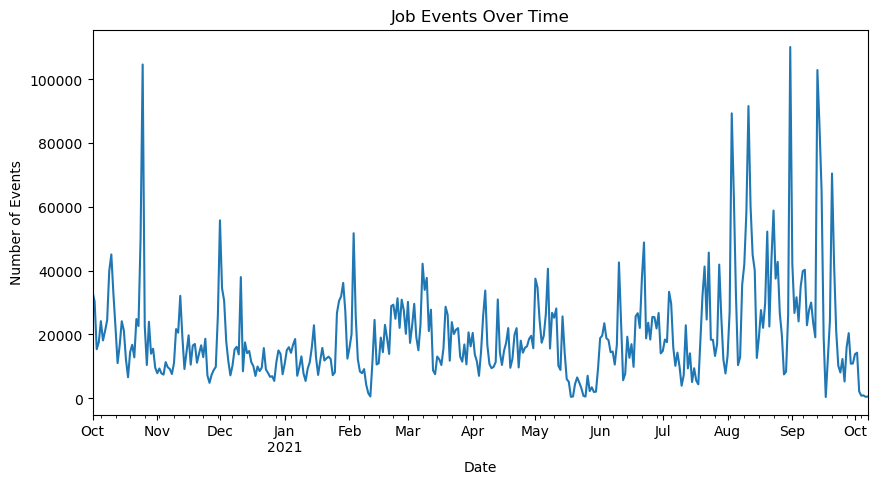

In [26]:
events_over_time = combined_data.resample('D').size()

events_over_time.plot(figsize=(10,5))
plt.title('Job Events Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.show()

* Job events over time by status

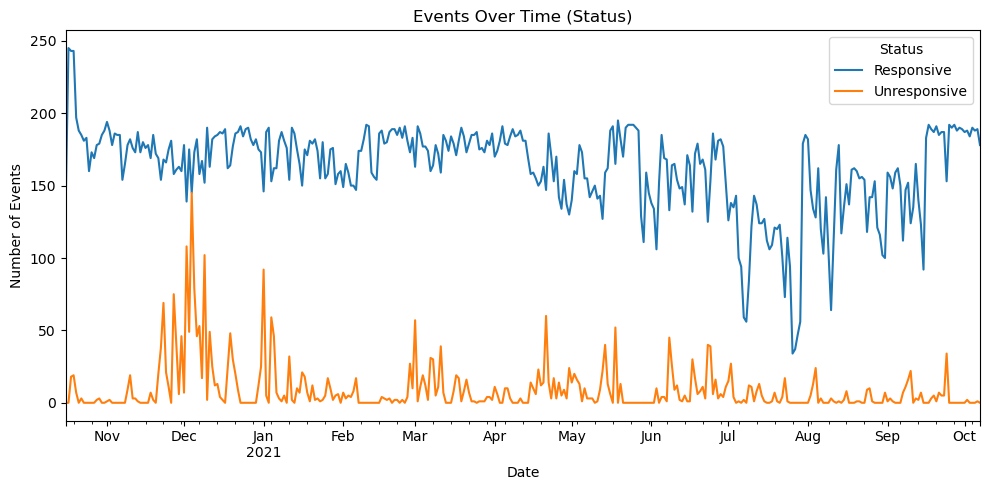

In [27]:
events_over_time = (
    combined_data.groupby([combined_data['Date'].dt.floor('D'), 'Status'])
      .size()
      .unstack(fill_value=0)
)


ax = events_over_time.plot(figsize=(10, 5))
ax.set_title('Events Over Time (Status)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Events')
plt.tight_layout()
plt.show()

* Distribution of Daily Job Events

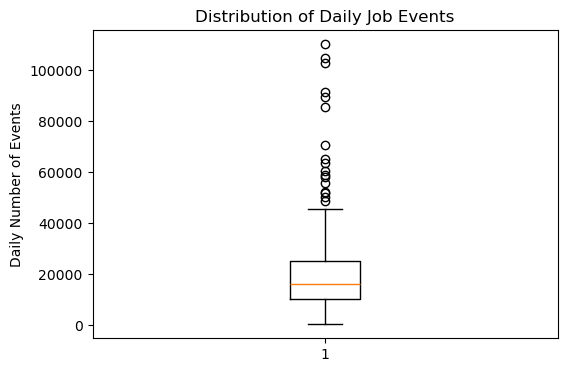

In [28]:
daily_counts = combined_data.resample('D').size()

plt.figure(figsize=(6,4))
plt.boxplot(daily_counts, vert=True)
plt.ylabel('Daily Number of Events')
plt.title('Distribution of Daily Job Events')
plt.show()

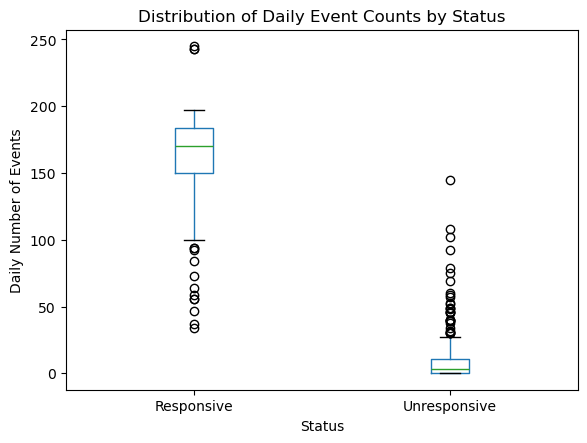

In [29]:
daily_by_status = (
    combined_data
    .groupby(['Status'])
    .resample('D')
    .size()
    .reset_index(name='DailyCount')
)

daily_by_status.boxplot(column='DailyCount', by='Status', grid=False, vert=True)
plt.title('Distribution of Daily Event Counts by Status')
plt.suptitle('')
plt.xlabel('Status')
plt.ylabel('Daily Number of Events')
plt.show()

* Summary statistics.

In [30]:
daily_counts.describe()

count       372.000000
mean      20044.303763
std       15593.989543
min         386.000000
25%       10409.750000
50%       16281.000000
75%       24993.250000
max      110095.000000
dtype: float64

* The visualizations show that job activity varies substantially over time, with most days exhibiting moderate levels of activity and occasional sharp spikes representing short-term bursts. Responsive jobs account for the majority of events, while unresponsive jobs are comparatively rare but tend to increase during periods of higher overall activity. The distribution of daily job counts is right-skewed, with the mean exceeding the median and a small number of extremely busy days driving much of the variability.

In [31]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


* Fit a simple logistic regression to test the hypothesis.

In [32]:
df = combined_data[combined_data['Status'].isin(['Responsive', 'Unresponsive'])].copy()

df['Unresponsive'] = (df['Status'] == 'Unresponsive').astype(int)

unresp_logreg = smf.logit(
    "Unresponsive ~ Events_5min",
    data=df.dropna(subset=['Unresponsive', 'Events_5min'])
).fit()



Optimization terminated successfully.
         Current function value: 0.204980
         Iterations 7


In [33]:

print(unresp_logreg.params)

Intercept     -3.596787
Events_5min    0.405795
dtype: float64


In [34]:
odds_ratio = np.exp(0.405795)
percent_increase = (odds_ratio - 1) * 100
print(f"Odds ratio: {odds_ratio:.3f}")
print(f"Percent increase in odds: {percent_increase:.1f}%")

Odds ratio: 1.500
Percent increase in odds: 50.0%


In [35]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

In [36]:
combined_data['Events_5min'].value_counts(dropna=False).head(10)

Events_5min
0.0     4589262
1.0     1840538
2.0      802098
3.0      168105
4.0       47702
5.0        5274
6.0        1535
7.0         995
11.0        414
9.0         241
Name: count, dtype: int64

In [37]:
events_value = 3
logit_p = unresp_logreg.params['Intercept'] + unresp_logreg.params['Events_5min']*events_value
print(f'Estimated Probability of Slurm Scheduler Unresponsiveness: {logistic(logit_p)}')

Estimated Probability of Slurm Scheduler Unresponsiveness: 0.08475700161730634


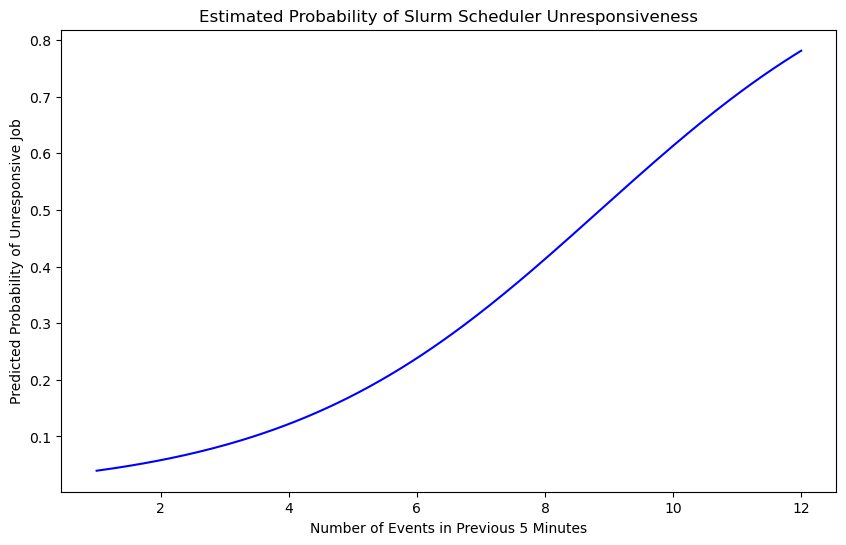

In [38]:
fit_df = pd.DataFrame({
    'Events_5min': np.linspace(start = df['Events_5min'].min(),
                            stop = df['Events_5min'].max(),
                            num = 200)
})

fit_df['fit'] = unresp_logreg.predict(fit_df)

fit_df.plot(x = 'Events_5min',
             y = 'fit',
             legend = False,
             figsize = (10,6),
             color = 'blue')
plt.title('Estimated Probability of Slurm Scheduler Unresponsiveness')
plt.ylabel('Predicted Probability of Unresponsive Job')
plt.xlabel('Number of Events in Previous 5 Minutes')
plt.show()

* The plot shows the estimated probability that the scheduler is unresponsive as a function of short-term job activity. The x-axis represents the number of job events occurring within the previous five-minute window, while the y-axis shows the predicted probability of unresponsiveness from the logistic regression model. The curve indicates that unresponsiveness becomes more likely as recent job activity increases, although the overall probability remains relatively low.

**Phase 4: Interpret and Conclude**

**Objectives:**

**Answer the main question:** Does the data support the hypothesis that the slurm scheduler is more likely to be unresponsive during bursts of job completions?
Summarize findings and limitations.

* The logistic regression results indicate that higher short-term job activity is significantly associated with increased slurm scheduler unresponsiveness, supporting the hypothesis that bursts of job completions raise the risk of unresponsiveness, although the analysis is observational and unresponsive events are rare.

**Findings:**
* The analysis shows that higher short-term job activity is associated with an increased likelihood of slurm scheduler unresponsiveness. Logistic regression results indicate that each additional job event within the previous five minutes increases the odds of unresponsiveness by approximately 50%, and predicted probabilities rise during burst periods, supporting the hypothesis that bursts of job completions are linked to elevated risk.

**Limitations:**
* The analysis is observational and does not establish causality. Unresponsive events are rare, which may affect the stability of estimates, and bursts are defined using a rolling activity measure that may not capture all factors influencing scheduler behavior.

**Notebook Sections:**

**Summarize evidence for or against the hypothesis.**

* The hypothesis proposes that the Slurm scheduler is more likely to be unresponsive during bursts of job completions. Exploratory analysis showed that job activity varies over time, with most periods having low activity and occasional short-term bursts. A logistic regression model using short-term job activity, measured by the number of events in the previous five minutes (Events_5min), found a positive and statistically significant relationship with scheduler unresponsiveness. Predicted probabilities from the model indicate that the likelihood of unresponsiveness increases during periods of higher recent activity, such as when multiple jobs occur within a five-minute window, compared to baseline low-activity periods.

**Conclusion**

* Overall, the results support the hypothesis that the slurm scheduler is more likely to be unresponsive during bursts of job completions. Although unresponsive events remain relatively rare, the estimated probability of unresponsiveness increases under higher short-term job activity. This analysis is observational and does not establish causality, but it provides consistent evidence of an association between bursty job activity and increased scheduler unresponsiveness.